In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
print(file.info())
                   

<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [43]:
file_US=file[file['job_country']=='United States'].copy()
file_US['job_posted_month']=file_US['job_posted_date'].dt.strftime('%b')
file_US


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_posted_month
1,Data Engineer,Data Engineer - MA,"Mesa, AZ",via Indeed,Full-time,False,Georgia,2023-03-13 12:51:23,True,True,United States,year,140000.0,NaN,Worldgate LLC,"['sql', 'nosql', 'java', 'python', 'kafka', 's...",Mar
2,Senior Data Analyst,Supervisory Information Technology Specialist ...,"Alexandria, VA",via ZipRecruiter,Full-time,False,"New York, United States",2023-07-05 07:03:38,True,False,United States,year,156000.0,NaN,National Technical Information Service,NaN,Jul
3,Machine Learning Engineer,Machine Learning Research Scientist,"Pittsburgh, PA",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-13 16:05:41,False,True,United States,year,140000.0,NaN,Bosch Group,"['pytorch', 'tensorflow']",Apr
4,Data Scientist,"Data Scientist, AWS","Irving, TX",via Snagajob,Full-time and Part-time,False,"Texas, United States",2023-10-15 06:02:51,False,False,United States,hour,NaN,39.795002,"Presidio, Inc.","['python', 'r', 'sql', 'c', 'aws', 'gcp', 'big...",Oct
6,Data Engineer,Sr. Data Engineer (remote),Anywhere,via Indeed,Full-time,True,"Texas, United States",2023-10-26 19:07:59,False,True,United States,year,135000.0,NaN,MultiPlan Inc.,"['python', 'java', 'sql', 'nosql', 'mongodb', ...",Oct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32666,Data Scientist,Principal Data Scientist,"Hartford, CT",via Ladders,Full-time,False,"New York, United States",2023-06-17 02:19:14,False,True,United States,year,150000.0,NaN,Cognizant Technology Solutions,NaN,Jun
32667,Senior Data Scientist,Senior Data Scientist,"Palo Alto, CA",via Indeed,Full-time,False,"California, United States",2023-08-29 18:05:55,False,True,United States,year,191000.0,NaN,Navan,"['go', 'python', 'sql', 'numpy', 'pandas', 'te...",Aug
32668,Data Analyst,eCommerce Data Analyst | Hybrid Work | W2 Acce...,"Austin, TX",via LinkedIn,Contractor,False,"Texas, United States",2023-03-15 19:01:41,False,False,United States,hour,NaN,42.500000,"TalentBurst, an Inc 5000 company","['python', 'excel']",Mar
32669,Data Scientist,Clinical Data Visualization Specialist - Remote,Anywhere,via ZipRecruiter,Full-time,True,"California, United States",2023-12-18 16:02:34,False,True,United States,hour,NaN,55.000000,Avispa Technology,"['sas', 'sas', 'python']",Dec


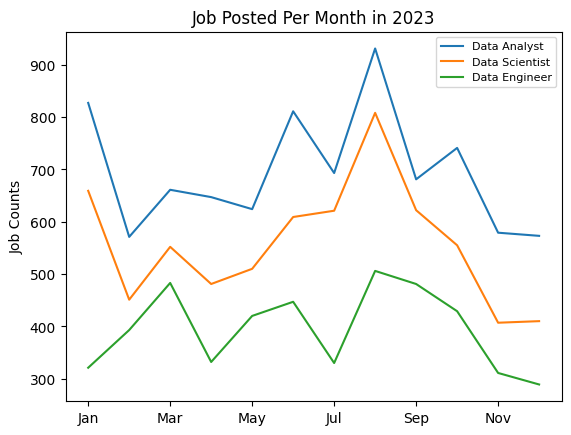

In [ ]:
file_US_pivot = file_US.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
file_US_pivot.reset_index(inplace=True)
file_US_pivot['month_no'] = pd.to_datetime(file_US_pivot['job_posted_month'], format='%b').dt.month
file_US_pivot.sort_values('month_no',inplace=True)
file_US_pivot.set_index('job_posted_month',inplace=True)
file_US_pivot.drop(columns='month_no',inplace=True)
top_3=file_US['job_title_short'].value_counts().head(3)
top_3=['Data Analyst','Data Scientist','Data Engineer']
top_3
file_US_pivot[top_3].plot(kind='line')
plt.ylabel('Job Counts')
plt.legend(fontsize=8)
plt.title('Job Posted Per Month in 2023')
plt.xlabel('')
plt.show()



In [82]:
file_US_pivot = file_US.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
file_US_pivot.reset_index(inplace=True)
file_US_pivot['month_no'] = pd.to_datetime(file_US_pivot['job_posted_month'], format='%b').dt.month
file_US_pivot.sort_values('month_no',inplace=True)
file_US_pivot['job_posted_month']=file_US_pivot['job_posted_month'].str.strip()
file_US_pivot.sort_values('month_no',inplace=True)
file_US_pivot.set_index('job_posted_month',inplace=True)
file_US_pivot.drop(columns='month_no',inplace=True)
top_3=file_US['job_title_short'].value_counts().head(3)
top_3=['Data Analyst','Data Scientist','Data Engineer']
top_3
file_US_pivot[top_3]

job_title_short,Data Analyst,Data Scientist,Data Engineer
job_posted_month,,,
Jan,827.0,659.0,321.0
Feb,571.0,451.0,393.0
Mar,661.0,552.0,483.0
Apr,647.0,481.0,332.0
May,624.0,510.0,420.0
Jun,811.0,609.0,447.0
Jul,693.0,621.0,330.0
Aug,931.0,808.0,506.0
Sep,681.0,622.0,481.0
